In [1]:
using Plots
using SpecialFunctions

# --- Parameters ---
g = 1.0           
t_max = 4.0       
j_vals = -10:10   
t_vals = range(0.0, t_max, length=200)

# The exact density for two non-interacting bosons starting at 0 and 1
function exact_density(j, t, g)
    x = -2.0 * g * t
    return abs2(besselj(j, x)) + abs2(besselj(j - 1, x))
end

# Preallocate the matrix
Z = zeros(length(t_vals), length(j_vals))

# Populate the matrix
for (col, j) in enumerate(j_vals)
    for (row, t) in enumerate(t_vals)
        Z[row, col] = exact_density(j, t, g)
    end
end

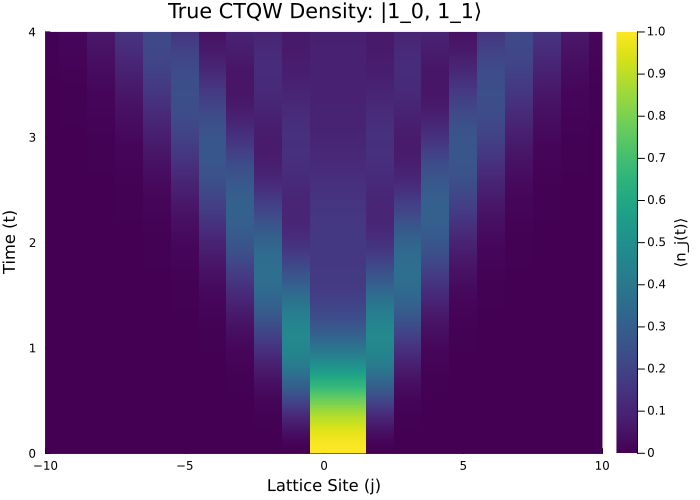

In [2]:
# --- Generate the Heatmap ---
heatmap(j_vals, t_vals, Z, 
        xlabel = "Lattice Site (j)", 
        ylabel = "Time (t)", 
        title = "True CTQW Density: |1_0, 1_1⟩",
        color = :viridis,
        colorbar_title = "⟨n_j(t)⟩",
        xlims = (minimum(j_vals), maximum(j_vals)),
        ylims = (0, t_max),
        size = (700, 500))